### Calculating the board

In [295]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [296]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [297]:
test_image_path = "../code/captured_images/image_83.jpg"

In [298]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_83.jpg: 480x640 1 Board, 1 White_start, 7.2ms
Speed: 0.8ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


In [299]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Board', 1: 'White_start'}
obb: None
orig_img: array([[[202, 207, 208],
        [203, 208, 209],
        [204, 209, 210],
        ...,
        [ 85, 113, 137],
        [ 92, 116, 140],
        [ 87, 111, 135]],

       [[201, 206, 207],
        [202, 207, 208],
        [204, 209, 210],
        ...,
        [ 97, 123, 147],
        [ 86, 110, 134],
        [ 73,  97, 121]],

       [[201, 207, 206],
        [202, 208, 207],
        [203, 208, 209],
        ...,
        [ 82, 107, 133],
        [ 97, 120, 146],
        [ 71,  92, 119]],

       ...,

       [[209, 205, 204],
        [209, 206, 202],
        [209, 205, 204],
        ...,
        [ 44,  56,  56],
        [ 55,  65,  65],
        [ 55,  65,  65]],

       [[207, 205, 205],
        [208, 206, 205],
        [209, 204, 205],
        ...,
        [ 2

In [300]:
def harris_corners(img, max_corners=4):

    """
    For finding the corners of the board for homography.
    Uses harris corner detector and then uses sort_corners
    before returning it as numpy array.
    Defaults to returning 4 corners.

    """


    # Harris response
    harris = cv2.cornerHarris(img, 15, 15, 0.04)
    harris = cv2.dilate(harris, None)

    # Normalize to 0–255 so goodFeaturesToTrack can use it
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX)
    harris_norm = np.uint8(harris_norm)

    corners = cv2.goodFeaturesToTrack(
        harris_norm,
        maxCorners=max_corners,
        qualityLevel=0.01,
        minDistance=60
    )

    corners = np.array([tuple(pt.ravel()) for pt in corners])
    corners = sort_corners(corners)


    if corners is None:
        Exception("No corners")

    return corners

def plot_corners(img, corners, radius=4, color=(0,0,255), thickness=-1):
    """
    Debugging function

    img: input image (grayscale or BGR)
    corners: list of (x, y) tuples
    """
    # Convert grayscale to BGR so colored dots show up
    if len(img.shape) == 2:
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = img.copy()

    for (x, y) in corners:
        cv2.circle(img_color, (int(x), int(y)), radius, color, thickness)

    return img_color

import numpy as np

def sort_corners(corners):
    """
    Sorts the corners from harris detector
    corners: list or array of 4 (x, y) points
    returns: array of points ordered as:
             top-left, top-right, bottom-right, bottom-left
    """

    pts = np.array(corners, dtype=np.float32)

    # Step 1: sort by y (top to bottom)
    pts = pts[np.argsort(pts[:,1])]

    # First two are top, last two are bottom
    top = pts[:2]
    bottom = pts[2:]

    # Step 2: sort left-to-right within each row
    top = top[np.argsort(top[:,0])]
    bottom = bottom[np.argsort(bottom[:,0])]

    # Order: TL, TR, BR, BL
    ordered = np.array([top[0],top[1], bottom[1], bottom[0]], dtype=np.float32)
    return ordered

In [301]:
def find_correct_rotation(homography, result, idx_board,idx_white):
    """
    This is for finding the correct rotation for the board s.t. 
    white is always at the bottom.
    
    
    """

    R90 = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ], dtype=np.float32)


    mid_point_x_white,mid_point_y_white = result[0].boxes.xywh[idx_white][0:2].cpu()
    mid_point_x_board,mid_point_y_board = result[0].boxes.xywh[idx_board][0:2].cpu()

    rotation = np.eye(3)
    while True:
        white_midpoint = cv2.perspectiveTransform(np.array([[[mid_point_x_white,mid_point_y_white]]]), homography)
        board_midpoint = cv2.perspectiveTransform(np.array([[[mid_point_x_board,mid_point_y_board]]]), homography)
        if np.squeeze(white_midpoint)[1]-np.squeeze(board_midpoint)[1] > 50: #Check that whitepoint y-point is sufficiently below board y-point

            return rotation
        else:
            homography = R90 @ homography
            rotation = R90@rotation


    
    


In [302]:
def calculate_homography(result):
    """
        Calculate and return the homography for BEV
        based on the board mask. Takes in a 
        results object from a YOLO model.
        The corners of a square in an image is points
        that are closest to the edges.
    """
    #This section of the code is to figure out which masks is for which object
    #It assumes only 1 detection for both
    detection_dict = result[0].names
    board_label = [k for k, v in detection_dict.items() if v == "Board"][0]
    white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
    objects_detected = result[0].boxes.cls
    idx_board = (objects_detected == board_label).nonzero(as_tuple=True)[0][0].item()
    idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()

    #This section finds the corners of the board, based on the board mask.
    board_mask = result[0].masks.xy[idx_board].astype(np.int32) #extract mask

    image = cv2.imread(test_image_path)
    zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


    mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
        [board_mask],
        isClosed=True,
        color=255,
        thickness=1
    )


    corners = harris_corners(mask_boundary) #Find the corners of the mask boundary


    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h,w = 480,480
    bev_pts = np.array([
        [0, 0],                        
        [480, 0],              
        [480, 480],    
        [0, 480]              
    ], dtype=np.float32).reshape(-1,1,2)




    H, _ = cv2.findHomography(corners, bev_pts) #Find the homography matrix

    padding = 0  #Padding, only for visualization

    T = np.array([ #Move the image s.t. padding is on all sides
        [1, 0, -padding/2],
        [0, 1, -padding/2],
        [0, 0, 1]
    ], dtype=np.float32)

    T_origin = np.array([  #Move the image to the origin, necessary for rotating
        [1, 0, -w/2],
        [0, 1, -h/2],
        [0, 0, 1]
    ], dtype=np.float32)
    
    T_from_origin = np.array([ #Move the image back from the origin
        [1, 0, w/2],
        [0, 1, h/2],
        [0, 0, 1]
    ], dtype=np.float32)
    

    rotation = find_correct_rotation(H,result,idx_board,idx_white) #Find the correct rotation, s.t. white is at the bottom


    return   T_from_origin @ rotation  @ T_origin @ T @ H



calculate_homography(result)


array([[    -2.1161,    0.024993,      927.77],
       [   0.015717,     -2.0982,      802.96],
       [ 0.00013014,  0.00040119,           1]])

In [303]:
model_pieces = YOLO("../code/runs/detect/train9/weights/best.pt")

In [304]:
result_pieces = model_pieces.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_83.jpg: 480x640 1 BB, 1 BK, 6 BPs, 1 BQ, 2 BRs, 1 WB, 1 WK, 1 WKN, 3 WPs, 1 WQ, 3 WRs, 5.0ms
Speed: 0.6ms preprocess, 5.0ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)


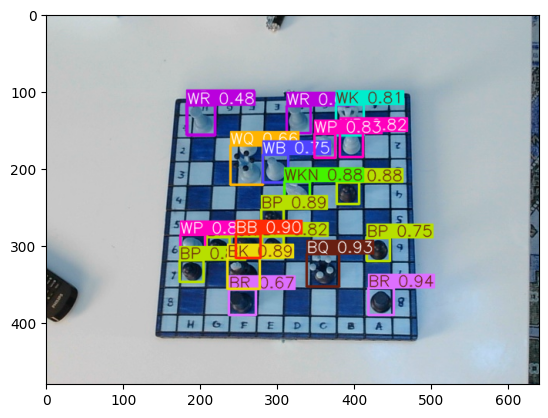

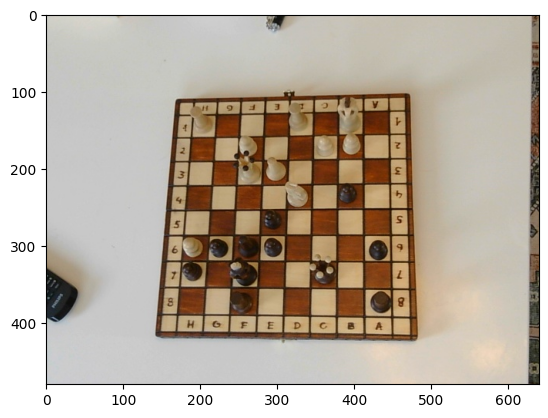

In [305]:
plt.imshow(result_pieces[0].plot())
plt.show()

image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()


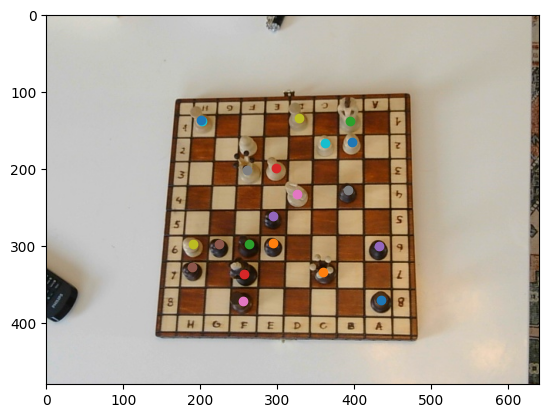

In [306]:
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()

    plt.scatter(x,y+h/2-20)

plt.show()

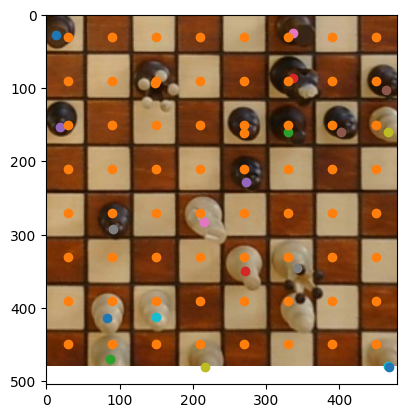

In [307]:
H = calculate_homography(result)
lower_y_coord = 20 #How many pixels from the bottom middle of the bounding box, we move



image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.warpPerspective(image,H,(480,480))
plt.imshow(image)


w,h = image.shape[0:2]

x = (np.linspace(0,w,9)+(w/16))[:-1]
y = (np.linspace(0,h,9)+(h/16))[:-1]

X, Y = np.meshgrid(x,y) #Define the middle points of the square




for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()
    piece_pos = cv2.perspectiveTransform(np.array([[[x,y+h/2-lower_y_coord]]]), H).squeeze()
    plt.scatter(piece_pos[0],piece_pos[1])


plt.scatter(X,Y)
plt.show()

In [308]:
transformed_positions = list()

for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()
    piece_pos = cv2.perspectiveTransform(np.array([[[x,y+h/2-lower_y_coord]]]), H).squeeze()
    transformed_positions.append(piece_pos)

transformed_positions = np.array(transformed_positions)


w,h = image.shape[0:2]

x = (np.linspace(0,w,9)+(w/16))[:-1]
y = (np.linspace(0,h,9)+(h/16))[:-1]


X,Y = np.meshgrid(x,y) #Define the middle points of the square

square_middles = np.stack([X.flatten(),Y.flatten()],axis=1)



diff = transformed_positions[:, None, :] - square_middles[None, :, :]




distances = np.linalg.norm(diff,axis=2)
idx = np.argmin(distances, axis=1)

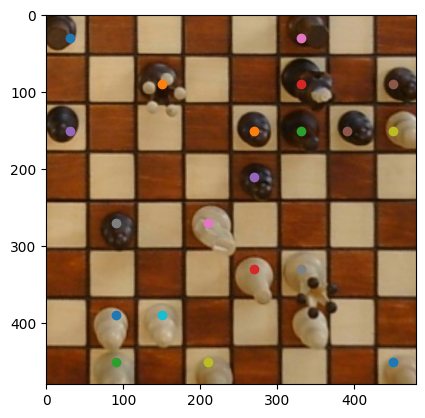

In [309]:
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.warpPerspective(image,H,(480,480))
plt.imshow(image)




for box in square_middles[idx]:

    plt.scatter(box[0],box[1])

In [310]:
board_positions = []


for i in range(8,0,-1):
    for letter in "ABCDEfGH":
        board_positions.append(f"{letter}{i}")

In [311]:
for i,position_index in enumerate(idx):
    name_dict = result_pieces[0].names
    piece_name =name_dict[int(result_pieces[0].boxes.cls[i].cpu())]


    print("We have piece",piece_name,"at position",board_positions[position_index])

We have piece BR at position A8
We have piece BQ at position C7
We have piece BB at position f6
We have piece BK at position f7
We have piece BP at position E5
We have piece BP at position H7
We have piece WKN at position D4
We have piece BP at position B4
We have piece WP at position H6
We have piece WP at position C2
We have piece WP at position B2
We have piece BP at position E6
We have piece WK at position B1
We have piece WB at position E3
We have piece BP at position A6
We have piece BP at position G6
We have piece BR at position f8
We have piece WQ at position f3
We have piece WR at position D1
We have piece WR at position H1
We have piece WR at position H1


In [312]:
# Build list of board squares A8 → H1
board_positions = []
for rank in range(8, 0, -1):
    for file in "ABCDEFGH":
        board_positions.append(f"{file}{rank}")

# Empty 8×8 board
board = [["" for _ in range(8)] for _ in range(8)]

# Your FEN mapping
fen_dict = {
    "WP": "P", "WR": "R", "WKN": "N", "WB": "B", "WQ": "Q", "WK": "K",
    "BP": "p", "BR": "r", "BKN": "n", "BB": "b", "BQ": "q", "BK": "k",
}

# Place pieces
for i, position_index in enumerate(idx):
    piece_label = result_pieces[0].names[int(result_pieces[0].boxes.cls[i].cpu())]
    fen_letter = fen_dict[piece_label]

    square = board_positions[position_index]
    file = ord(square[0]) - ord("A")      # 0–7
    rank = 8 - int(square[1])             # 0–7

    board[rank][file] = fen_letter

# Convert board → FEN
fen_ranks = []
for row in board:
    fen_row = ""
    empty = 0
    for cell in row:
        if cell == "":
            empty += 1
        else:
            if empty > 0:
                fen_row += str(empty)
                empty = 0
            fen_row += cell
    if empty > 0:
        fen_row += str(empty)
    fen_ranks.append(fen_row)

fen_board = "/".join(fen_ranks)

# Final FEN (no castling/en-passant yet)
fen = f"{fen_board} w - - 0 1"

print("FEN:", fen)


FEN: r4r2/2q2k1p/p3pbpP/4p3/1p1N4/4BQ2/1PP5/1K1R3R w - - 0 1


In [313]:
import chess
board = chess.Board(fen)

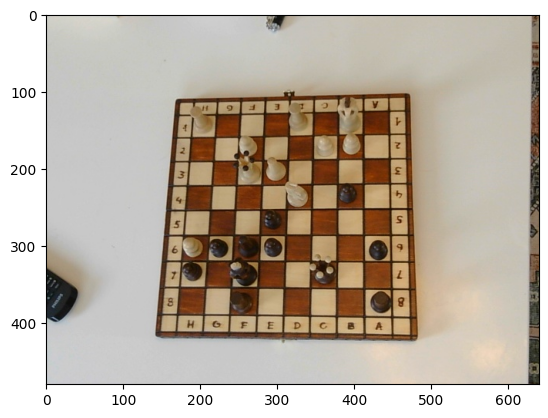

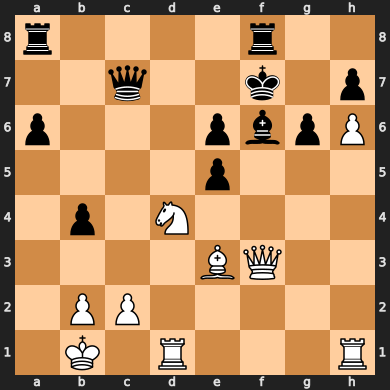

In [314]:

image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
board